# Traffic flow forecasting with tgdata

Load the traffic-flow datasets, look at their node signals and graph, and turn them into
batches of forecasting samples.

Setup (once): install tgdata with plotting and log in to Hugging Face, since the
datasets are private to the `tgdata-hub` organisation.

```bash
pip install "tgdata[plot] @ git+ssh://git@github.com/FabriDeCastelli/tgdata.git"
hf auth login
```

To open this file as a notebook: `jupytext --to notebook traffic_flow.py`, or run its
cells directly in VS Code / PyCharm.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import ConcatDataset, DataLoader

import tgdata
from tgdata.plot import plot_forecast, plot_heatmap, plot_signals
from tgdata.sampling import MultiDatasetSampler, collate_pad

# Downloads land here once, then load offline. On a shared server, point it at a large disk.
ROOT = Path(os.environ.get("TGDATA_ROOT", Path.home() / ".cache" / "tgdata"))
torch.manual_seed(0)
print("tgdata", tgdata.__version__)

tgdata 0.1.0


## What is available

Datasets are grouped by domain. Names such as `largest-d5` are node subsets of a stored
dataset (here one PeMS district of LargeST); they load like any other dataset.

In [2]:
for domain, names in tgdata.domains().items():
    print(f"{domain}: {names}")
print("pretraining pool:", tgdata.list(domain="traffic_flow", pool=True))

traffic_flow: ['largest', 'largest-d10', 'largest-d11', 'largest-d12', 'largest-d3', 'largest-d4', 'largest-d5', 'largest-d6', 'largest-d7', 'largest-d8', 'largest-gba', 'largest-gla', 'largest-sd', 'pems03', 'pems04', 'pems07', 'pems08']
pretraining pool: ['largest-d10', 'largest-d11', 'largest-d12', 'largest-d3', 'largest-d4', 'largest-d5', 'largest-d6', 'largest-d7', 'largest-d8', 'pems03', 'pems04', 'pems07', 'pems08']


## Load one dataset

`load` downloads PEMS08 (38 MB) the first time and memory-maps it afterwards, so arrays
are read from disk only when sliced.

In [3]:
g = tgdata.load("pems08", root=ROOT)
print(g.name, "|", g.domain, "|", g.meta["source"])
print(f"x          {g.x.shape}  {g.x.dtype}   [steps, nodes, channels] = {g.meta['channels']}")
print(f"covariates {g.covariates.shape}   {g.meta['covariate_channels']}")
print(f"mask       {g.mask.shape}      observed: {g.mask.mean():.2%} ({g.meta['mask_rule']})")
print(f"timestamps {g.timestamps.shape}  every {g.meta['freq']}, "
      f"{np.datetime64(int(g.timestamps[0]), 's')} to {np.datetime64(int(g.timestamps[-1]), 's')}")
print(f"edges      {g.edge_index.shape}  weights: {g.meta['edge_weight']['kind']}, "
      f"used as {g.meta['adjacency']['kind']} ({g.meta['adjacency']['formula']})")
print("default task:", g.meta["default_task"])

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

pems08 | traffic_flow | Caltrans PeMS District 8, ASTGCN release (Guo et al., 2019)
x          (17856, 170, 1)  float32   [steps, nodes, channels] = ['flow']
covariates (17856, 170, 2)   ['occupancy', 'speed']
mask       (17856, 170)      observed: 99.65% (flow != 0)
timestamps (17856,)  every 5min, 2016-07-01T00:00:00 to 2016-08-31T23:55:00
edges      (2, 277)  weights: distance, used as binary (w_ij = 1 for every (i, j) row of the csv, 0 otherwise; directed)
default task: {'name': 'node_forecasting', 'params': {'window': 12, 'horizon': 12}, 'reference': 'ASTGCN-r-pytorch configurations/PEMS08_astgcn.conf: len_input = 12, num_for_predict = 12, in_channels = 1'}


## Node signals

One week of flow for three sensors. Missing readings are drawn as gaps.

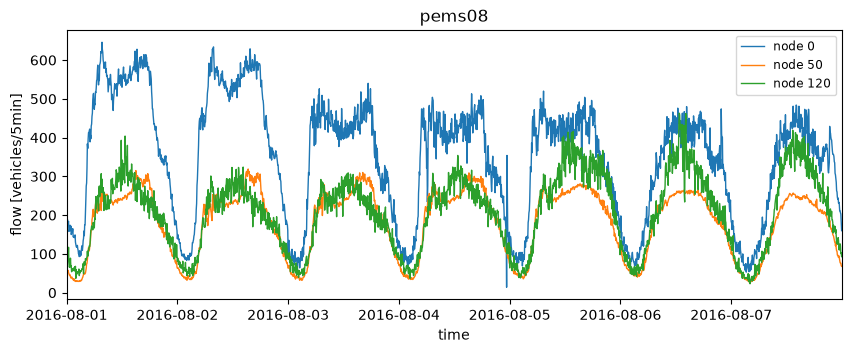

In [4]:
plot_signals(g, nodes=[0, 50, 120], start="2016-08-01", end="2016-08-08")
plt.show()

All sensors over the same week: daily cycles show up as vertical bands, missing readings
as white.

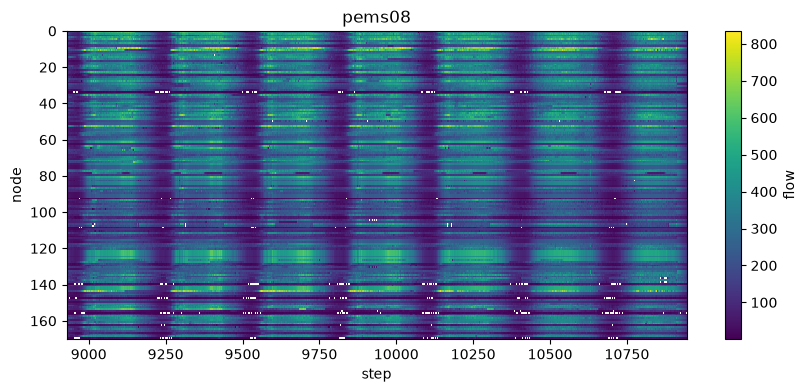

In [5]:
start = int(np.searchsorted(g.timestamps, np.datetime64("2016-08-01", "s").astype(np.int64)))
plot_heatmap(g, start=start, end=start + 7 * 288)
plt.show()

Mean flow by time of day over the training steps, and the sensor graph as an adjacency
matrix (edges as the ASTGCN paper uses them).

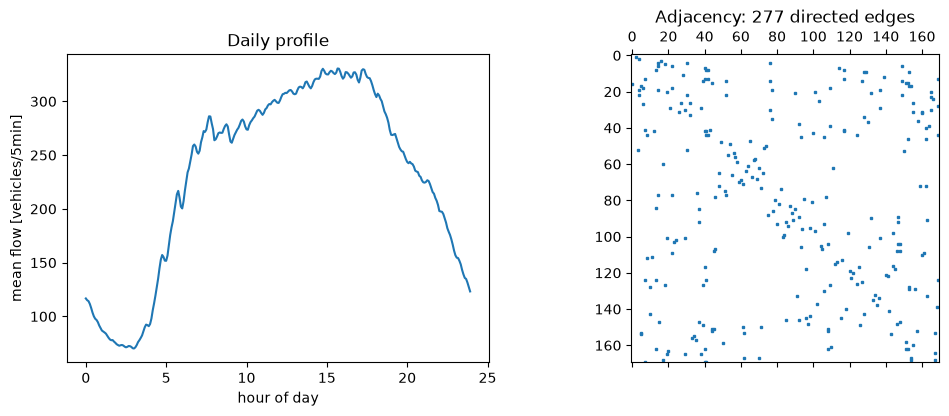

In [6]:
steps_per_day = 288
train_end = g.splits["default"].resolve(g.num_steps)["train"][1]
x = np.where(g.mask[:train_end], g.x[:train_end, :, 0], np.nan)
days = train_end // steps_per_day
daily = np.nanmean(x[: days * steps_per_day].reshape(days, steps_per_day, -1), axis=(0, 2))

edge_index, edge_weight = tgdata.adjacency(g)
A = np.zeros((g.num_nodes, g.num_nodes))
A[edge_index[0], edge_index[1]] = edge_weight

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(np.arange(steps_per_day) / 12, daily)
ax1.set(xlabel="hour of day", ylabel="mean flow [vehicles/5min]", title="Daily profile")
ax2.spy(A, markersize=1.5)
ax2.set(title=f"Adjacency: {edge_index.shape[1]} directed edges")
plt.show()

## Forecasting samples

`g.task()` builds the task the dataset's source defines: 12 steps (1 hour) in, 12 out,
with the ASTGCN split. Each sample is a dictionary of tensors.

In [7]:
train, test = g.task(split="train"), g.task(split="test")
print(f"train {len(train)} samples, test {len(test)} samples")

sample = test[0]
for key, value in sample.items():
    print(f"{key:12s} {tuple(value.shape) if hasattr(value, 'shape') else value}")

train 10699 samples, test 3567 samples
x            (12, 170, 1)
y            (12, 170, 1)
t            14278
mask_x       (12, 170, 1)
mask_y       (12, 170, 1)
covariates   (24, 170, 2)
timestamps   (24,)
edge_index   (2, 277)
edge_weight  (277,)


/Users/fabriziodecastelli/Desktop/PhD/year1/tgdata/tgdata/tasks/__init__.py:19: UserWarning: CUDA is not available; tgdata tasks build batches on the CPU
  return TASKS[name](g, **params)


A persistence baseline (repeat the last input value) against the target, for two sensors.

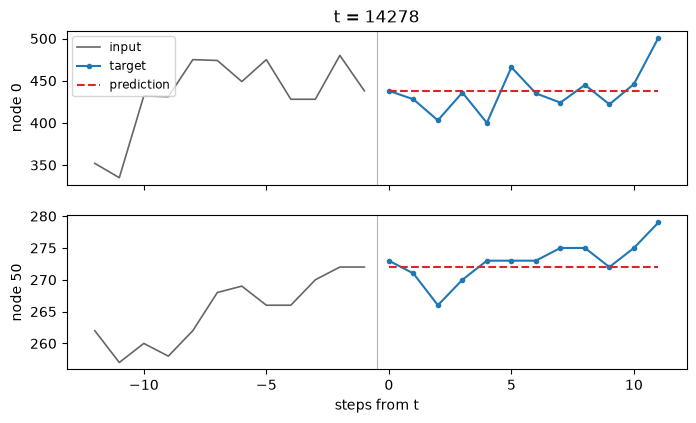

In [8]:
persistence = sample["x"][-1:].expand_as(sample["y"])
plot_forecast(sample, nodes=[0, 50], prediction=persistence)
plt.show()

The input window of one sample as an image, nodes by time.

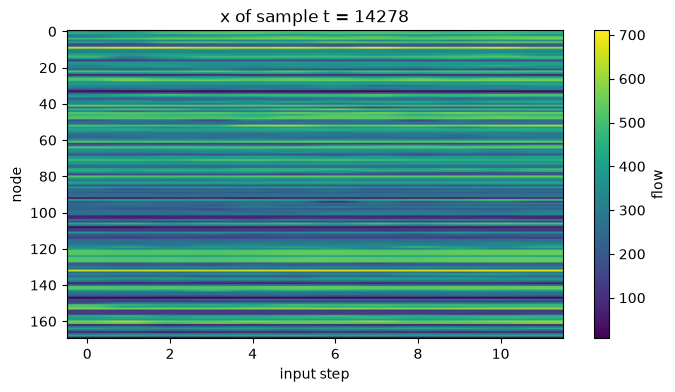

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
image = ax.imshow(sample["x"][..., 0].T, aspect="auto", cmap="viridis")
fig.colorbar(image, ax=ax, label="flow")
ax.set(xlabel="input step", ylabel="node", title=f"x of sample t = {sample['t']}")
plt.show()

Batches: the task knows its collate function. `normalize="channel"` scales by the
training-split statistics stored with the dataset.

In [10]:
task = g.task(split="train", normalize="channel")
loader = DataLoader(task, batch_size=32, shuffle=True, collate_fn=task.collate)
batch = next(iter(loader))
for key, value in batch.items():
    shape = tuple(value.shape) if hasattr(value, "shape") else f"list of {len(value)}"
    print(f"{key:12s} {shape}")
print("normalised x: mean", batch["x"].mean().item(), "std", batch["x"].std().item())

x            (32, 12, 170, 1)
y            (32, 12, 170, 1)
t            (32,)
mask_x       (32, 12, 170, 1)
mask_y       (32, 12, 170, 1)
covariates   (32, 24, 170, 2)
timestamps   (32, 24)
edge_index   (2, 277)
edge_weight  (277,)
normalised x: mean -0.1869407445192337 std 0.9793903231620789


Masked MAE of persistence on the test split, in vehicles per 5 minutes.

In [11]:
errors, counts = 0.0, 0
for batch in DataLoader(test, batch_size=256, collate_fn=test.collate):
    prediction = batch["x"][:, -1:].expand_as(batch["y"])
    valid = batch["mask_y"].expand_as(batch["y"])
    errors += (prediction - batch["y"]).abs()[valid].sum().item()
    counts += valid.sum().item()
print(f"persistence masked MAE on PEMS08 test: {errors / counts:.2f}")

persistence masked MAE on PEMS08 test: 25.28


## Several datasets at once

Pretraining draws each batch from one dataset, chosen with probability proportional to
size^(1/temperature), and pads nodes to the largest graph in the batch. Only the small
PeMS datasets are used here; set `INCLUDE_LARGEST = True` to add the nine LargeST districts
(a one-time 4.3 GB download).

In [12]:
INCLUDE_LARGEST = False

names = tgdata.list(domain="traffic_flow", pool=True)
if not INCLUDE_LARGEST:
    names = [n for n in names if not n.startswith("largest")]
tasks = [tgdata.load(n, root=ROOT).task(split="train", normalize="channel") for n in names]
sampler = MultiDatasetSampler([len(t) for t in tasks], batch_size=16, num_batches=200,
                              temperature=2.0, seed=0)
pool = DataLoader(ConcatDataset(tasks), batch_sampler=sampler, collate_fn=collate_pad)

for name, t, p in zip(names, tasks, sampler.probs, strict=True):
    print(f"{name:14s} {len(t):6d} samples, {t.g.num_nodes:4d} nodes, picked with p = {p:.2f}")
batch = next(iter(pool))
print("batch x", tuple(batch["x"].shape))
print("real nodes per sample", batch["node_mask"].sum(1).tolist())

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

pems03          15701 samples,  358 nodes, picked with p = 0.27
pems04          10181 samples,  307 nodes, picked with p = 0.22
pems07          16911 samples,  883 nodes, picked with p = 0.28
pems08          10699 samples,  170 nodes, picked with p = 0.23
batch x (16, 12, 170, 1)
real nodes per sample [170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170, 170]
